In [1]:
import torch
import matplotlib.pyplot as plt
import sys, os
sys.path.append('../')
from dinov2.models.vision_transformer import vit_large
import yaml


XFORMERS_ENABLED= True


/nfs/data/1/rrazakami/work/dinov2ForLArTPC/tests/../dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/nfs/data/1/rrazakami/work/dinov2ForLArTPC/tests/../dinov2/layers/attention.py:29: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/nfs/data/1/rrazakami/work/dinov2ForLArTPC/tests/../dinov2/layers/block.py:34: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


### Load the student model from the config and checkpoint files

In [8]:
path_to_config = '../out_cvn_memlite/config.yaml'
with open(path_to_config, 'r') as f:
    config = yaml.safe_load(f)

In [9]:
path_to_config = '../out_cvn_memlite/config.yaml'
with open(path_to_config, 'r') as f:
    config = yaml.safe_load(f)
student_model = vit_large(
    patch_size=config['student']['patch_size'],
    drop_path_rate=config['student']['drop_path_rate'],
    init_values=config['student']['layerscale'],
    drop_path_uniform=config['student']['drop_path_uniform'],
    block_chunks=config['student']['block_chunks'],
    ffn_layer=config['student']['ffn_layer'],
    interpolate_offset=config['student']['interpolate_offset']
)

In [57]:
checkpoint = torch.load('../out_cvn_memlite_1GPU/model_final.rank_0.pth', map_location='cpu')
state_dict = checkpoint['model']
new_state_dict = {
    k.replace('student.backbone.', ''): v 
    for k, v in state_dict.items() 
    if k.startswith('student.backbone.')
}

In [59]:
student_model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [86]:
attention_maps = {}
def get_attention_hook(name):
    def hook(module, input, output):
        print(f'Hook called for {name}, output type {type(output)}')
        print(f'Output shape: {output.shape}')
        attention_maps[name] = output
    return hook

for name, module in student_model.named_modules():
    if module.__class__.__name__ == 'MemEffAttention':
        # print(name, module)
        module.register_forward_hook(get_attention_hook(name))
print(f"\nHooks registered. Now running forward pass...")
print(f"attention_maps before forward: {len(attention_maps)} items")


Hooks registered. Now running forward pass...
attention_maps before forward: 0 items


In [100]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Get features from different layers
first_layer = attention_maps['block_0']  # Early layer
last_layer = list(attention_maps.values())[-1]  # Last layer

# Remove batch dimension
first_features = first_layer[0]  # [197, 1024]
last_features = last_layer[0]   # [197, 1024]

print(f"First layer features shape: {first_features.shape}")
print(f"Last layer features shape: {last_features.shape}")

# Separate CLS token and patch tokens
first_cls = first_features[0]      # [1024]
first_patches = first_features[1:]  # [196, 1024]

last_cls = last_features[0]
last_patches = last_features[1:]

print(f"\nCLS token feature: {first_cls.shape}")
print(f"Patch tokens features: {first_patches.shape}")

First layer features shape: torch.Size([197, 1024])
Last layer features shape: torch.Size([197, 1024])

CLS token feature: torch.Size([1024])
Patch tokens features: torch.Size([196, 1024])


### Read the training metrics

In [105]:
import json
import numpy as np
# batch size = 2
path_to_metrics = '../out_cvn_memlite/training_metrics.json'
with open(path_to_metrics, 'r') as f:
    metrics = None
    for i, line in enumerate(f):
        metrics_dict = json.loads(line)
        dtype = [(key, type(metrics_dict[key])) for key in metrics_dict.keys()]
        # print(dtype)
        if i==0:
            metrics = np.array([tuple(metrics_dict.values())], dtype=dtype)
        else:
            metrics = np.append(metrics, np.array([tuple(metrics_dict.values())], dtype=dtype), axis=0)
# batch size = 16
path_to_metrics_batch16 = '../out_cvn_memlite_batchpergpu_16/training_metrics.json'
with open(path_to_metrics_batch16, 'r') as f:
    metrics_batch16 = None
    for i, line in enumerate(f):
        metrics_dict = json.loads(line)
        dtype = [(key, type(metrics_dict[key])) for key in metrics_dict.keys()]
        # print(dtype)
        if i==0:
            metrics_batch16 = np.array([tuple(metrics_dict.values())], dtype=dtype)
        else:
            metrics_batch16 = np.append(metrics_batch16, np.array([tuple(metrics_dict.values())], dtype=dtype), axis=0)

In [106]:
metrics.dtype

dtype([('iteration', '<i8'), ('iter_time', '<f8'), ('data_time', '<f8'), ('lr', '<f8'), ('wd', '<f8'), ('mom', '<f8'), ('last_layer_lr', '<f8'), ('current_batch_size', '<f8'), ('total_loss', '<f8'), ('dino_local_crops_loss', '<f8'), ('dino_global_crops_loss', '<f8'), ('koleo_loss', '<f8'), ('ibot_loss', '<f8')])

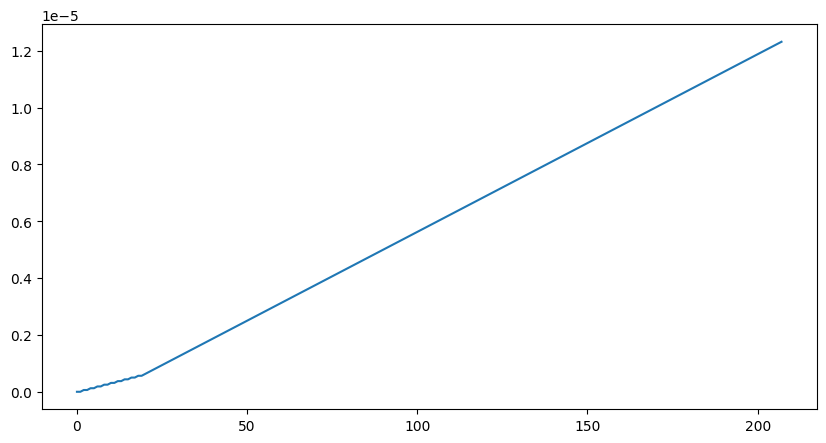

In [107]:
plt.figure(figsize=(10,5))
plt.plot(metrics['iteration'], metrics['lr'], label='learning rate')
plt.show()

In [108]:
losses_keys = [k for k in metrics.dtype.names if 'loss' in k]

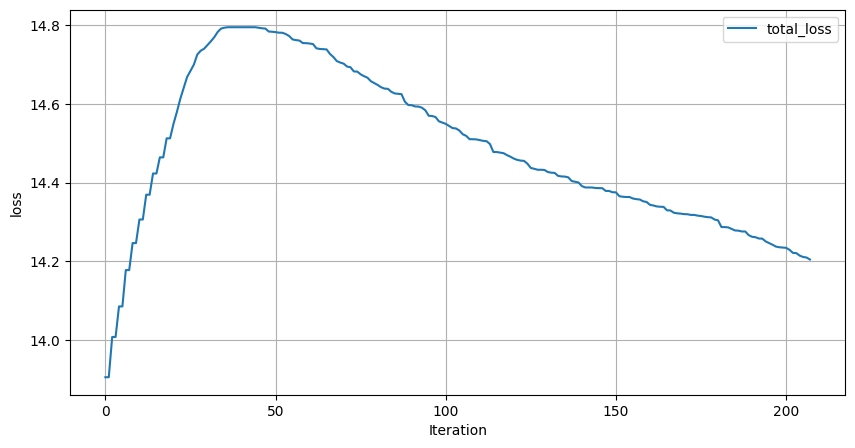

In [109]:
plt.figure(figsize=(10,5))
plt.plot(metrics['iteration'], metrics['total_loss'], label='total_loss')
# plt.xlim(0, 3000)
plt.xlabel('Iteration')
plt.ylabel('loss')
plt.grid(True)
plt.legend()
plt.show()

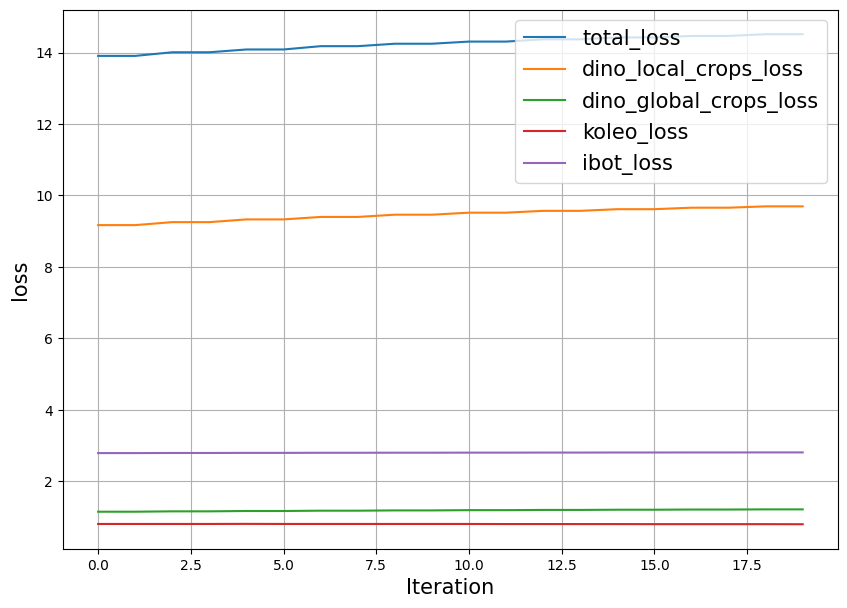

In [90]:
plt.figure(figsize=(10,7))
for k in losses_keys:
    plt.plot(metrics['iteration'], metrics[k], label=k)
plt.xlabel('Iteration', fontsize=15)
plt.ylabel('loss', fontsize=15)
plt.grid(True)
plt.legend(fontsize=15)
plt.show()

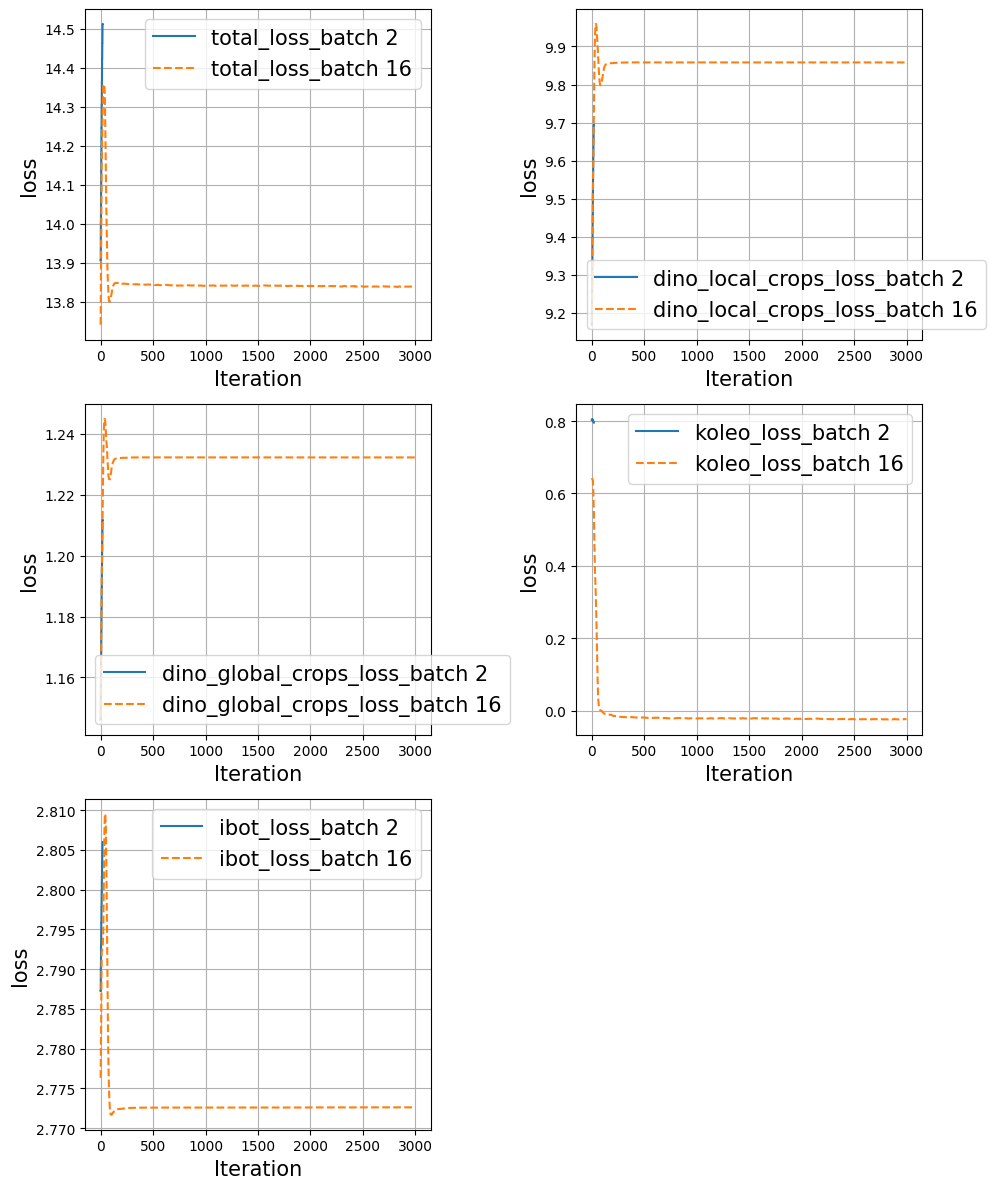

In [91]:
# fig, axes = plt.subplots(5,1, figsize=(5,4*5))

# for i, k in enumerate(losses_keys):
#     axes[i].plot(metrics['iteration'], metrics[k], label=k)
#     axes[i].set_xlabel('Iteration', fontsize=15)
#     axes[i].set_ylabel('loss', fontsize=15)
#     axes[i].grid(True)
#     axes[i].legend(fontsize=15)
# plt.show()
fig, axes = plt.subplots(3, 2, figsize=(5*2, 4*3))

for i, k in enumerate(losses_keys):
    if i < 6:  # Only plot first 6 losses (3x2 = 6 subplots)
        row = i // 2  # Calculate row index
        col = i % 2   # Calculate column index
        axes[row, col].plot(metrics['iteration'], metrics[k], label=k+'_batch 2')
        axes[row, col].plot(metrics_batch16['iteration'], metrics_batch16[k], label=k+'_batch 16', linestyle='--')
        axes[row, col].set_xlabel('Iteration', fontsize=15)
        axes[row, col].set_ylabel('loss', fontsize=15)
        axes[row, col].grid(True)
        axes[row, col].legend(fontsize=15)

# Hide empty subplots if you have fewer than 6 losses
for i in range(len(losses_keys), 6):
    row = i // 2
    col = i % 2
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Peak memory usage vs iteration

In [12]:
import json
with open('eval_mem_runtime.json', 'r') as f:
    data = json.load(f)
# with open('/nfs/data/1/rrazakami/work/dinov2ForLArTPC/out_cvn_memlite_batchpergpu_16/eval_mem_runtime.json', 'r') as f:
#     data_batch16 = json.load(f)

In [13]:
data.keys()

dict_keys(['runtime', 'peak_memory', 'total_training_time_s'])

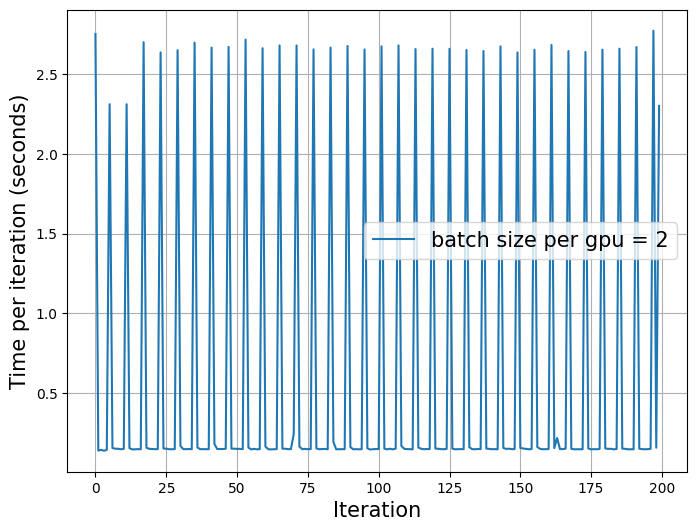

Total runtime of all iterations : 1.95 minutes


In [15]:
plt.figure(figsize=(8,6))
plt.plot(data['runtime']['iteration'], np.array(data['runtime']['time_per_iteration_s']), label='batch size per gpu = 2')
# plt.plot(data_batch16['runtime']['iteration'], np.array(data_batch16['runtime']['time_per_iteration_s']), label='batch size per gpu = 16')
# plt.xlim(0,100)
# plt.ylim(0.1,0.2)
plt.xlabel('Iteration', fontsize=15)
# plt.yscale('log')
plt.ylabel('Time per iteration (seconds)', fontsize=15)
# plt.title('MY BENCHMARKING DINO v2')
plt.legend(fontsize=15)
plt.grid(True)
plt.show()
print(f'Total runtime of all iterations : {np.sum(np.array(data["runtime"]["time_per_iteration_s"]))/60:.2f} minutes')

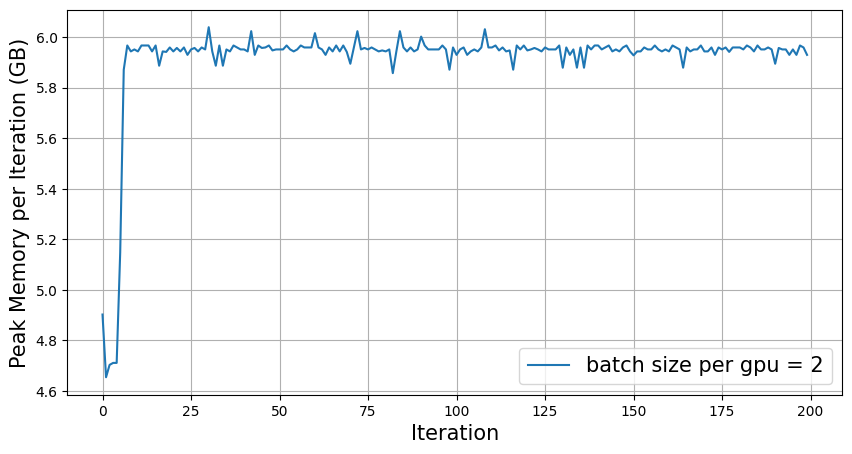

In [17]:
plt.figure(figsize=(10,5))
plt.plot(data['peak_memory']['iteration'], np.array(data['peak_memory']['peak_memory_GB']), label='batch size per gpu = 2')
# plt.plot(data_batch16['peak_memory']['iteration'], np.array(data_batch16['peak_memory']['peak_memory_GB']), label='batch size per gpu = 16')
# plt.xlim(0,100)
plt.xlabel('Iteration', fontsize=15)
plt.ylabel('Peak Memory per Iteration (GB)', fontsize=15)
plt.legend(fontsize=15)
plt.grid(True)
plt.show()

## Visualize attention map

In [14]:
# Copyright (c) Facebook, Inc. and its affiliates.
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#     http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Note the original is here: https://github.com/facebookresearch/dino/blob/main/visualize_attention.py

import os
import sys
import yaml
sys.path.append('../')
# import argparse
# import cv2
# import random
# import colorsys
# import requests
# from io import BytesIO

# import skimage.io
# from skimage.measure import find_contours
import matplotlib.pyplot as plt
# from matplotlib.patches import Polygon
import torch
import torch.nn as nn
# import torchvision
from torchvision import transforms as pth_transforms
import numpy as np
from PIL import Image
from dinov2.models.vision_transformer import vit_small, vit_large


# image_size = (168, 168)
# output_dir = '.'
# patch_size = 16
image_size = (952, 952)
output_dir = '.'
patch_size = 14

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# path_to_config = '../out_cvn_memlite/config.yaml'
# with open(path_to_config, 'r') as f:
#     config = yaml.safe_load(f)
# model = vit_large(
#     patch_size=config['student']['patch_size'],
#     drop_path_rate=config['student']['drop_path_rate'],
#     init_values=config['student']['layerscale'],
#     drop_path_uniform=config['student']['drop_path_uniform'],
#     block_chunks=config['student']['block_chunks'],
#     ffn_layer=config['student']['ffn_layer'],
#     interpolate_offset=config['student']['interpolate_offset']
# )
model = vit_large(
        patch_size=14,
        img_size=526,
        init_values=1.0,
        #ffn_layer="mlp",
        block_chunks=0
)

dictionary_pth = torch.load('dinov2_vitg14_pretrain.pth')
print(dictionary_pth.keys())
continue
model.load_state_dict(torch.load('dinov2_vitg14_pretrain.pth'))
for p in model.parameters():
    p.requires_grad = False
model.to(device)
model.eval()
print(model)
continue
img = Image.open('cow-on-the-beach2.jpg')
img = img.convert('RGB')
transform = pth_transforms.Compose([
    pth_transforms.Resize(image_size),
    pth_transforms.ToTensor(),
    pth_transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
img = transform(img)
print(img.shape)

# make the image divisible by the patch size
w, h = img.shape[1] - img.shape[1] % patch_size, img.shape[2] - img.shape[2] % patch_size
img = img[:, :w, :h].unsqueeze(0)

w_featmap = img.shape[-2] // patch_size
h_featmap = img.shape[-1] // patch_size

print(img.shape)

attentions = model.get_last_selfattention(img.to(device))

nh = attentions.shape[1] # number of head

# we keep only the output patch attention
# for every patch
attentions = attentions[0, :, 0, 1:].reshape(nh, -1)
# weird: one pixel gets high attention over all heads?
print(torch.max(attentions, dim=1)) 
attentions[:, 283] = 0 

attentions = attentions.reshape(nh, w_featmap, h_featmap)
attentions = nn.functional.interpolate(attentions.unsqueeze(0), scale_factor=patch_size, mode="nearest")[0].cpu().numpy()

# save attentions heatmaps
os.makedirs(output_dir, exist_ok=True)

for j in range(nh):
    fname = os.path.join(output_dir, "attn-head" + str(j) + ".png")
    plt.imsave(fname=fname, arr=attentions[j], format='png')
    print(f"{fname} saved.")


dict_keys(['cls_token', 'pos_embed', 'mask_token', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.qkv.bias', 'blocks.0.attn.proj.weight', 'blocks.0.attn.proj.bias', 'blocks.0.ls1.gamma', 'blocks.0.norm2.weight', 'blocks.0.norm2.bias', 'blocks.0.mlp.w12.weight', 'blocks.0.mlp.w12.bias', 'blocks.0.mlp.w3.weight', 'blocks.0.mlp.w3.bias', 'blocks.0.ls2.gamma', 'blocks.1.norm1.weight', 'blocks.1.norm1.bias', 'blocks.1.attn.qkv.weight', 'blocks.1.attn.qkv.bias', 'blocks.1.attn.proj.weight', 'blocks.1.attn.proj.bias', 'blocks.1.ls1.gamma', 'blocks.1.norm2.weight', 'blocks.1.norm2.bias', 'blocks.1.mlp.w12.weight', 'blocks.1.mlp.w12.bias', 'blocks.1.mlp.w3.weight', 'blocks.1.mlp.w3.bias', 'blocks.1.ls2.gamma', 'blocks.2.norm1.weight', 'blocks.2.norm1.bias', 'blocks.2.attn.qkv.weight', 'blocks.2.attn.qkv.bias', 'blocks.2.attn.proj.weight', 'blocks.2.attn.proj.bias', 'blocks.2.ls1.gamma', 'blocks.2.nor

SyntaxError: 'continue' not properly in loop (2929247024.py, line 71)